In [33]:
EXPERIMENT = "pattern"
SAVE_FIGURES = False

# Imports

In [34]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 22})

from tqdm import tqdm

import os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".95"

In [35]:
if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    os.makedirs("figures", exist_ok=True)

# Pattern Forward Model

This copy runs the three-cell-type pattern adhesion model: salt-and-pepper with shell.


In [36]:
from pathlib import Path
import importlib
import importlib.util
import json
from collections import namedtuple

NOTEBOOK_DIR = Path.cwd()

import pattern_istate_and_model as pattern_model

importlib.reload(pattern_model)

from IPython.display import Image as DisplayImage, display
import random
import numpy as onp

In [37]:
FORWARD_OUTDIR = NOTEBOOK_DIR / "pattern_forward_outputs"
FORWARD_OUTDIR.mkdir(exist_ok=True)

PATTERN = "salt-pepper-shell"
J=np.array([3.8,0.8,0.9,3.8,0.8,0.9])  # [J11, J12, J13, J22, J23, J33]
# J = np.array([1.1834648347841823, 3.6904302594962823, 1.742595177537159, 0.8670169813167008, 2.031255535131428, 1.4907168894174556])  # [J11, J12, J13, J22, J23, J33]
J = np.array([3.614412361158708, 1.0782926789150458, 2.0167727236962225, 1.065922175583557, 1.7594971027528967, 3.638234058704631])
DEFAULT_LOSS_KWARGS = dict(
    shell_distance_weight=10,
    w12=1,
    w33=1,
    w_media1=5,
    w_media2=5,
    w_media3=5,
)
N_CELLS = 100
TYPE_RATIOS = np.array([21,20,79])  # [type1, type2, type3]
HIDE_TYPES = [3]  # one-based cell types to hide, e.g. [3] hides type 3
N_STEPS = 1000
SEED = random.randint(0, 1000000)
# SEED = 0

key = jax.random.PRNGKey(SEED)
key, init_key, sim_key = jax.random.split(key, 3)

istate_pattern = pattern_model.build_istate(init_key, n_cells=N_CELLS, type_ratios=TYPE_RATIOS)
model_pattern = pattern_model.build_model(J, initial_type_fractions=TYPE_RATIOS / TYPE_RATIOS.sum())
trajectory_pattern = jxm.simulate(model_pattern, istate_pattern, sim_key, N_STEPS, history=True)
if isinstance(trajectory_pattern, tuple):
    trajectory_pattern = trajectory_pattern[0]
fstate_pattern = jax.tree_util.tree_map(lambda x: x[-1], trajectory_pattern)

initial_loss = float(pattern_model.pattern_loss(istate_pattern, pattern=PATTERN, **DEFAULT_LOSS_KWARGS))
loss = float(pattern_model.pattern_loss(fstate_pattern, pattern=PATTERN, **DEFAULT_LOSS_KWARGS))
print(f"Initial loss: {initial_loss:.3f}")
print(f"Final loss: {loss:.3f}")


Initial loss: -14.977
Final loss: -28.941


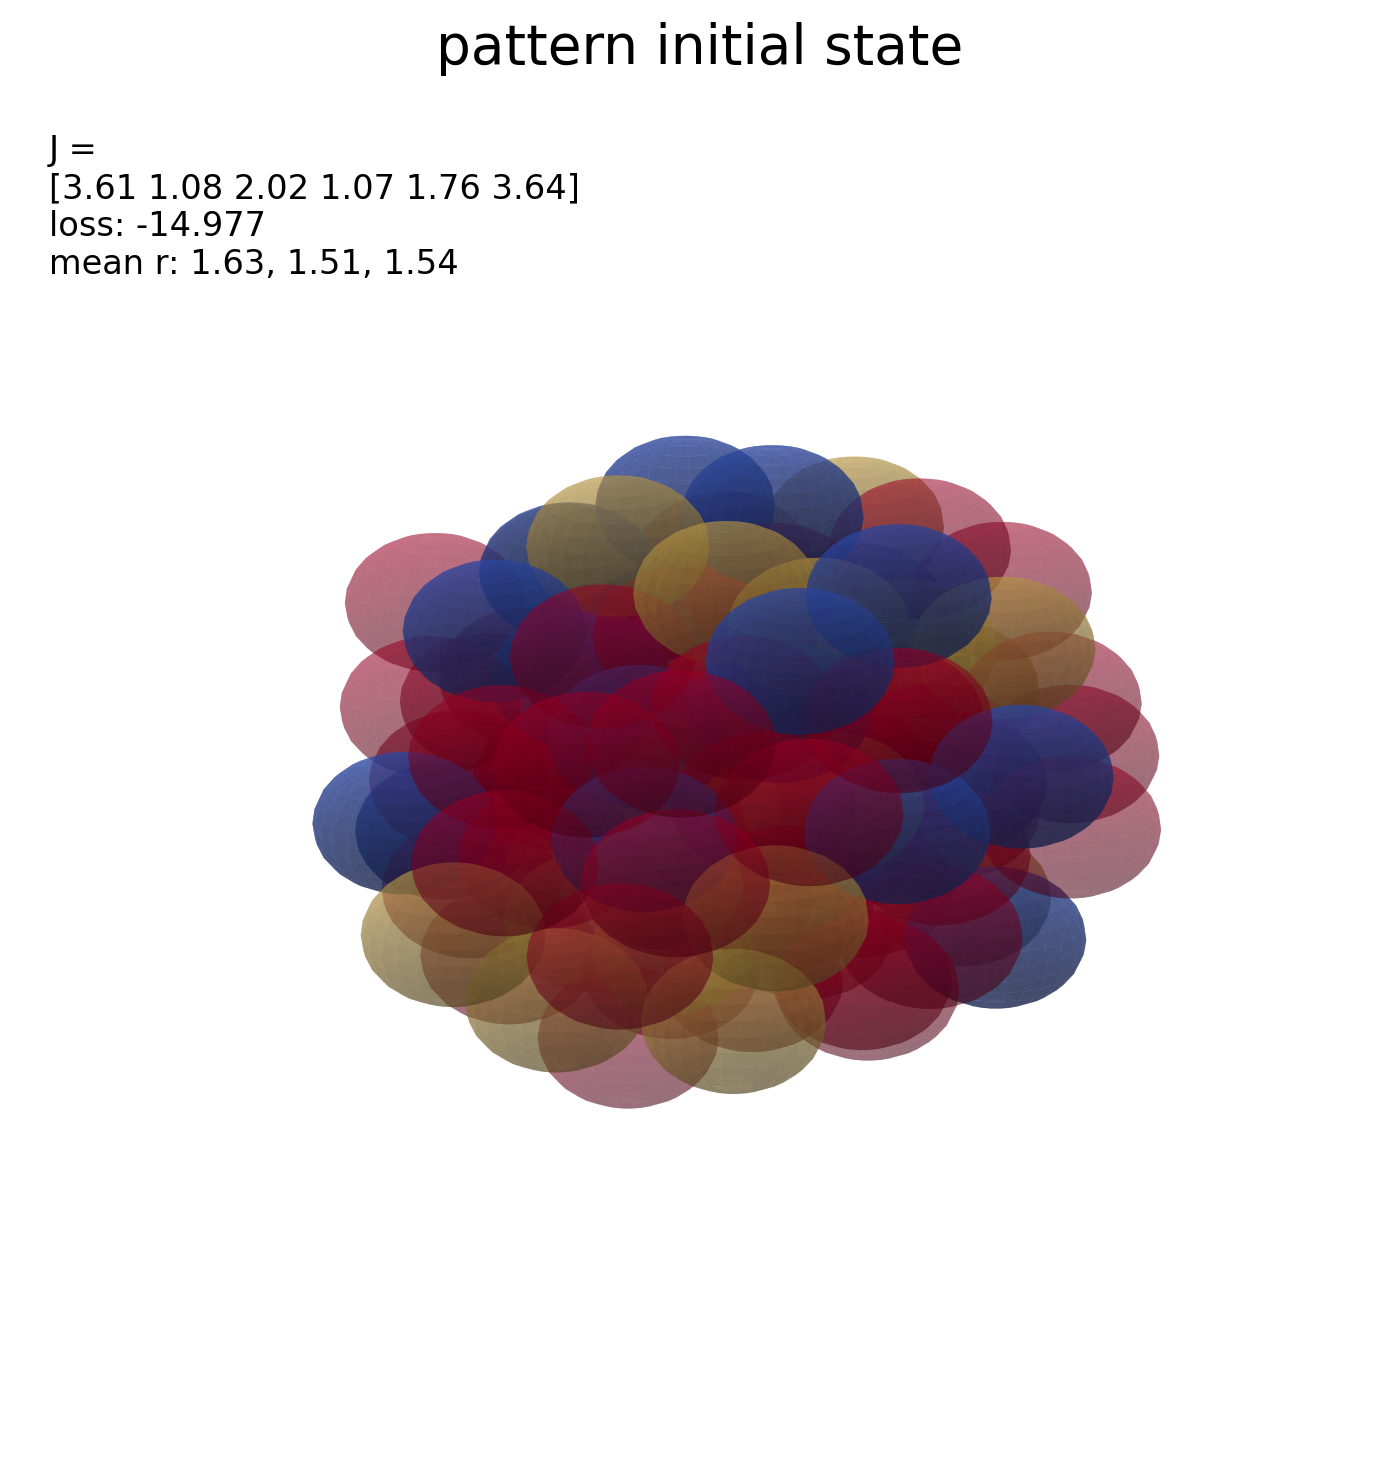

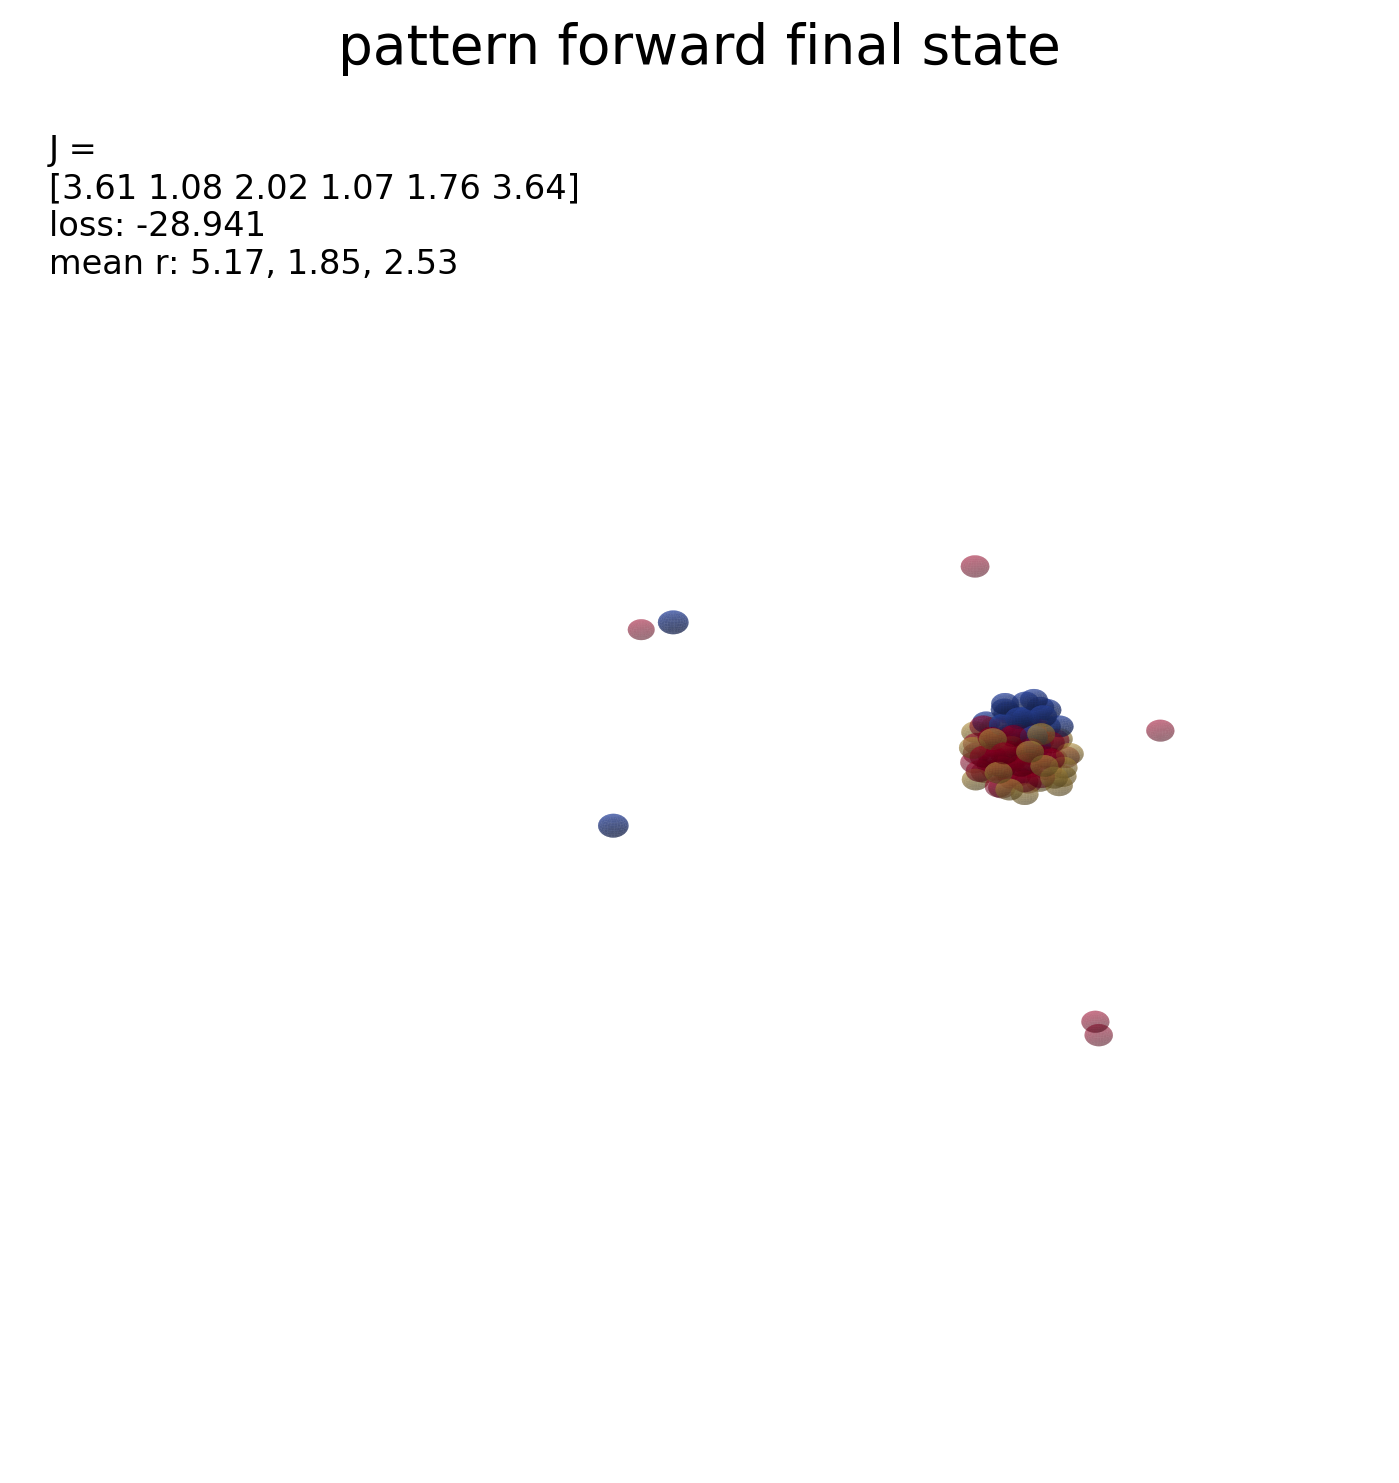

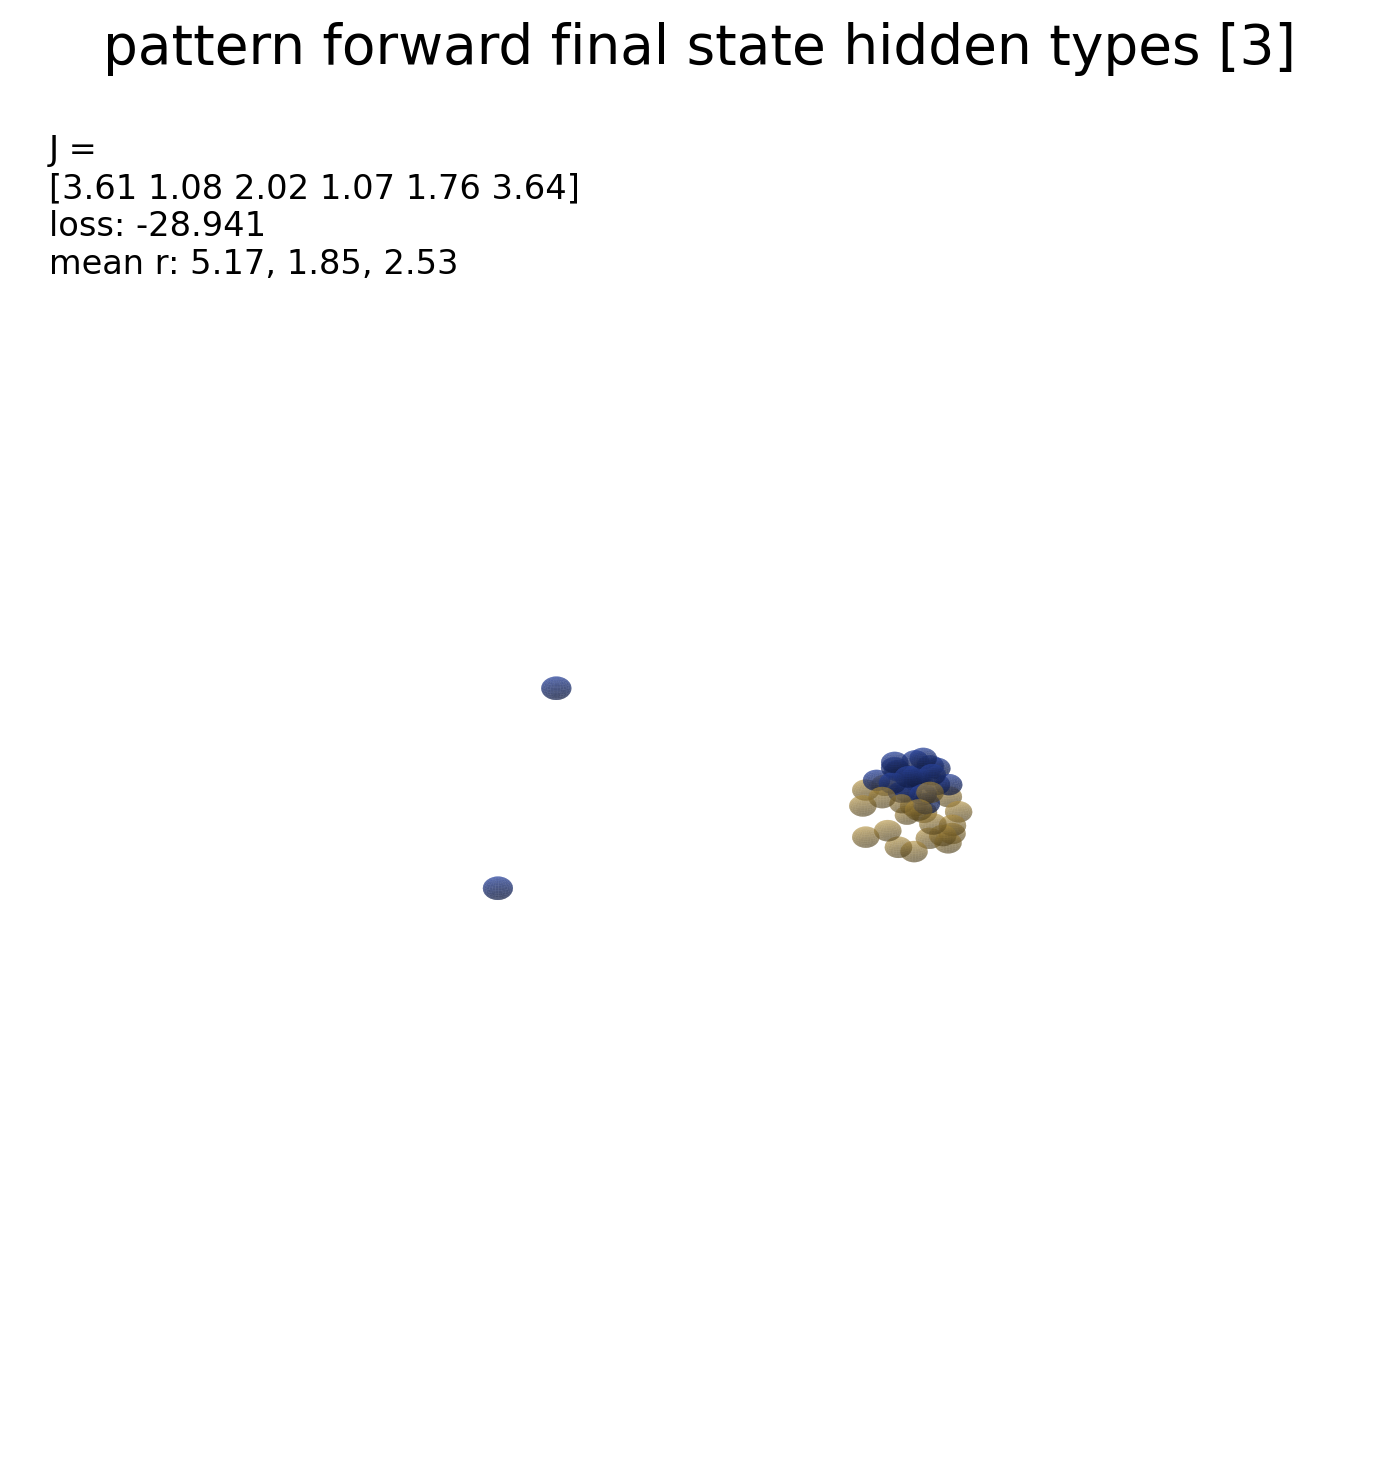

In [38]:
def _load_translucent_sphere_plotter(notebook_dir):
    plot_path = Path(notebook_dir) / "translucent-3d-plotting.py"
    spec = importlib.util.spec_from_file_location("translucent_3d_plotting", plot_path)
    sphere_plotting = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(sphere_plotting)
    return sphere_plotting.plot_translucent_spheres


# compute mean radius for each cell type
def pattern_metrics(state, *, pattern, **loss_kwargs):
    positions = onp.asarray(state.position)
    type_idx = onp.asarray(onp.argmax(state.celltype, axis=1))
    metrics = {"loss": float(pattern_model.pattern_loss(state, pattern=pattern, **loss_kwargs))}
    for i in range(3):
        mask = type_idx == i
        if onp.any(mask):
            type_positions = positions[mask]
            type_center = type_positions.mean(axis=0)
            dist = onp.sqrt(onp.sum((type_positions - type_center) ** 2, axis=-1) + 1e-8)
            metrics[f"mean_radius_type_{i + 1}"] = float(onp.mean(dist))
        else:
            metrics[f"mean_radius_type_{i + 1}"] = 0.0
        metrics[f"count_type_{i + 1}"] = int(onp.sum(mask))
    return metrics


def visible_cell_mask(state, hidden_types=None):
    hidden_types = set(hidden_types or [])
    if not hidden_types:
        return None
    type_idx = onp.asarray(onp.argmax(state.celltype, axis=1)) + 1
    return ~onp.isin(type_idx, list(hidden_types))


def hidden_filename(filename, hidden_types):
    path = Path(filename)
    hidden_tag = "-hidden-" + "-".join(str(t) for t in hidden_types)
    return f"{path.stem}{hidden_tag}{path.suffix}"


def save_pattern_state_visualization(*, outdir, state, title, filename, target_j, pattern, hidden_types=None, **loss_kwargs):
    outdir = Path(outdir)
    outdir.mkdir(exist_ok=True)
    path = outdir / filename
    hidden_types = list(hidden_types or [])
    plot_translucent_spheres = _load_translucent_sphere_plotter(NOTEBOOK_DIR)
    metrics = pattern_metrics(state, pattern=pattern, **loss_kwargs)

    plot_translucent_spheres(state, path, title, metrics, target_j)
    result = {"path": str(path), "hidden_path": None, "metrics": metrics}

    if hidden_types:
        hidden_path = outdir / hidden_filename(filename, hidden_types)
        cell_mask = visible_cell_mask(state, hidden_types)
        hidden_title = f"{title} hidden types {hidden_types}"
        plot_translucent_spheres(state, hidden_path, hidden_title, metrics, target_j, cell_mask=cell_mask)
        result["hidden_path"] = str(hidden_path)

    return result


def display_preview(preview, width=420):
    display(DisplayImage(filename=preview["path"], width=width))
    if preview.get("hidden_path") is not None:
        display(DisplayImage(filename=preview["hidden_path"], width=width))


initial_preview = save_pattern_state_visualization(
    outdir=FORWARD_OUTDIR,
    state=istate_pattern,
    title="pattern initial state",
    filename="pattern-initial-state.png",
    target_j=J,
    pattern=PATTERN,
    **DEFAULT_LOSS_KWARGS,
)

final_preview = save_pattern_state_visualization(
    outdir=FORWARD_OUTDIR,
    state=fstate_pattern,
    title="pattern forward final state",
    filename="pattern-forward-final-state.png",
    target_j=J,
    pattern=PATTERN,
    hidden_types=HIDE_TYPES,
    **DEFAULT_LOSS_KWARGS,
)

display_preview(initial_preview, width=420)
display_preview(final_preview, width=420)

## Contact And Pair-Distance Diagnostics


In [39]:
PAIR_LABELS = [(0, 0), (0, 1), (0, 2), (1, 1), (1, 2), (2, 2)]
PAIR_NAMES = ["11", "12", "13", "22", "23", "33"]


def contact_frequency_summary(state):
    return {
        name: float(pattern_model.contact_frequency(state, i, j))
        for name, (i, j) in zip(PAIR_NAMES, PAIR_LABELS)
    }


def pair_distance_groups(state):
    positions = onp.asarray(state.position)
    type_idx = onp.asarray(onp.argmax(state.celltype, axis=1))
    groups = {name: [] for name in PAIR_NAMES}

    for a in range(positions.shape[0]):
        for b in range(a + 1, positions.shape[0]):
            i = int(type_idx[a])
            j = int(type_idx[b])
            if i > j:
                i, j = j, i
            name = f"{i + 1}{j + 1}"
            groups[name].append(float(onp.linalg.norm(positions[a] - positions[b])))

    return {name: onp.asarray(values) for name, values in groups.items()}


def save_pair_distance_distribution(*, state, outdir, filename, title):
    outdir = Path(outdir)
    outdir.mkdir(exist_ok=True)
    path = outdir / filename
    groups = pair_distance_groups(state)

    fig, ax = plt.subplots(figsize=(9, 5))
    for name in PAIR_NAMES:
        values = groups[name]
        if values.size == 0:
            continue
        ax.hist(values, bins=24, alpha=0.42, density=True, label=f"{name} (n={values.size})")

    ax.set_xlabel("cell-pair distance")
    ax.set_ylabel("density")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    plt.close(fig)
    return {"path": str(path), "groups": groups}


def show_contact_and_distance_diagnostics(*, state, outdir, filename, title):
    contact_freqs = contact_frequency_summary(state)
    print(title)
    print(json.dumps(contact_freqs, indent=2))
    distance_plot = save_pair_distance_distribution(
        state=state,
        outdir=outdir,
        filename=filename,
        title=title,
    )
    display(DisplayImage(filename=distance_plot["path"], width=520))
    return {"contact_frequencies": contact_freqs, "distance_plot": distance_plot}

## Loss Contribution Diagnostics


In [40]:
def resolved_loss_kwargs(**loss_kwargs):
    kwargs = DEFAULT_LOSS_KWARGS.copy()
    kwargs.update(loss_kwargs)
    return kwargs


def loss_contribution_summary(state, *, pattern, model=None, target_fractions=None, w_frac=0.0, **loss_kwargs):
    kwargs = resolved_loss_kwargs(**loss_kwargs)
    raw = {
        "contact_12": float(pattern_model.contact_frequency(state, 0, 1)),
        "contact_33": float(pattern_model.contact_frequency(state, 2, 2)),
        "shell_distance_loss": float(pattern_model.shell_distance_loss(state)),
        "media_contact_1": float(pattern_model.media_contact_frequency(state, 0)),
        "media_contact_2": float(pattern_model.media_contact_frequency(state, 1)),
        "media_contact_3": float(pattern_model.media_contact_frequency(state, 2)),
    }

    if pattern == "salt-pepper-shell":
        weighted = {
            "shell_distance": kwargs["shell_distance_weight"] * raw["shell_distance_loss"],
            "media_1_penalty": kwargs["w_media1"] * raw["media_contact_1"],
            "media_2_penalty": kwargs["w_media2"] * raw["media_contact_2"],
            "media_3_reward": -kwargs["w_media3"] * raw["media_contact_3"],
            "contact_33_penalty": kwargs["w33"] * raw["contact_33"],
            "contact_12_reward": -kwargs["w12"] * raw["contact_12"],
        }
    else:
        raise ValueError(f"Unknown pattern: {pattern}")

    if model is not None and target_fractions is not None and w_frac > 0.0:
        learned_fractions = onp.asarray(pattern_model.visible_fractions_from_raw_fractions(model.raw_fractions))
        target_fractions = onp.asarray(target_fractions)
        raw["frac_penalty"] = float(onp.sum((learned_fractions - target_fractions) ** 2))
        weighted["frac_penalty"] = float(w_frac) * raw["frac_penalty"]

    return {
        "pattern": pattern,
        "weights": kwargs | {"w_frac": float(w_frac)},
        "raw": raw,
        "weighted": weighted,
        "weighted_total": float(sum(weighted.values())),
        "pattern_loss": float(pattern_model.pattern_loss(state, pattern=pattern, **kwargs)),
    }


def print_loss_contribution_summary(title, state, *, pattern, model=None, target_fractions=None, w_frac=0.0, **loss_kwargs):
    summary = loss_contribution_summary(
        state,
        pattern=pattern,
        model=model,
        target_fractions=target_fractions,
        w_frac=w_frac,
        **loss_kwargs,
    )
    print(title)
    print("weighted terms:")
    print(json.dumps(summary["weighted"], indent=2))
    print(f"weighted_total: {summary['weighted_total']:.6f}")
    print(f"pattern_loss: {summary['pattern_loss']:.6f}")
    return summary


In [41]:
manual_final_loss_breakdown = print_loss_contribution_summary(
    "manual final state loss breakdown",
    fstate_pattern,
    pattern=PATTERN,
    **DEFAULT_LOSS_KWARGS,
)

manual final state loss breakdown
weighted terms:
{
  "shell_distance": -30.241615940726124,
  "media_1_penalty": 1.1957923218022541,
  "media_2_penalty": 1.0390830765655577,
  "media_3_reward": -1.0073812276249936,
  "contact_33_penalty": 0.09221026579868707,
  "contact_12_reward": -0.01864229132948574
}
weighted_total: -28.940554
pattern_loss: -28.940554


manual forward final pair distances
{
  "11": 0.1365597319344758,
  "12": 0.01864229132948574,
  "13": 0.039928256914936525,
  "22": 0.035264700477329734,
  "23": 0.05848354864216704,
  "33": 0.09221026579868707
}


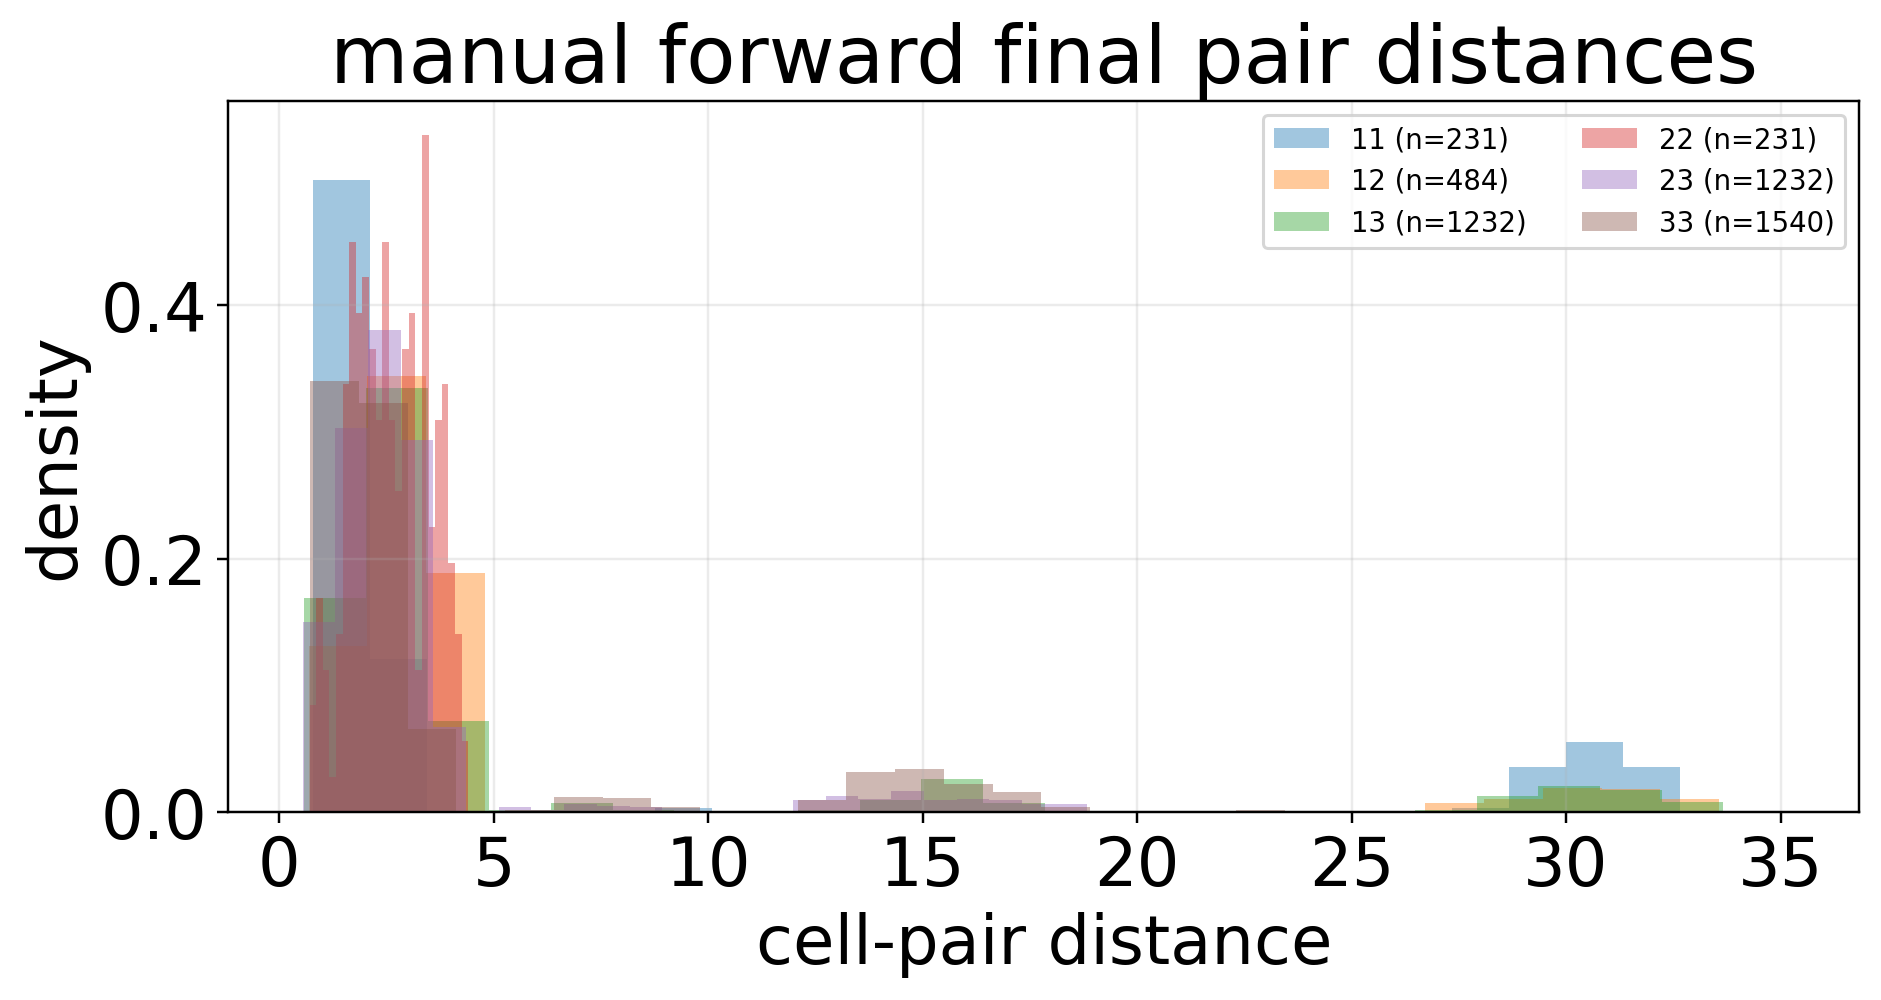

In [42]:
manual_distance_diagnostics = show_contact_and_distance_diagnostics(
    state=fstate_pattern,
    outdir=FORWARD_OUTDIR,
    filename="pattern-forward-pair-distance-distribution.png",
    title="manual forward final pair distances",
)

In [43]:
# animation_outputs = forward_viz.save_forward_animation(
#     outdir=FORWARD_OUTDIR,
#     istate=istate_pattern,
#     trajectory=trajectory_pattern,
# )

# animation_outputs["animation"]

## Morse Potential Trace During Pattern Forward Simulation


In [44]:
import jax_md
from jax_morph.utils import discount_tangent


def morse_energy_trace_over_relaxation(model, istate, key, *, n_steps=50, relaxation_steps=100):
    relaxation_model = pattern_model.build_relaxation_model_from_raw_j(model.raw_j)
    relaxer = relaxation_model.substeps[0]
    mech_potential = relaxer.mechanical_potential

    energy_fn = mech_potential.energy_fn(istate)
    init, apply = jax_md.simulate.brownian(
        energy_fn,
        istate.shift,
        dt=relaxer.dt,
        kT=relaxer.kT,
        gamma=relaxer.gamma,
    )

    outer_keys = jax.random.split(key, n_steps)

    def one_outer_step(position, outer_key):
        opt_state = init(outer_key, position)

        def one_relaxation_step(opt_state, _):
            opt_state = apply(opt_state)
            opt_state = eqx.tree_at(
                lambda s: s.position,
                opt_state,
                replace_fn=lambda p: discount_tangent(p, relaxer.discount),
            )
            return opt_state, energy_fn(opt_state.position)

        opt_state, energies = jax.lax.scan(one_relaxation_step, opt_state, xs=None, length=relaxation_steps)
        return opt_state.position, energies

    final_position, energy_blocks = jax.lax.scan(one_outer_step, istate.position, outer_keys)
    final_state = eqx.tree_at(lambda s: s.position, istate, final_position)
    energy = energy_blocks.reshape(-1)

    return {
        "energy": energy,
        "outer_step": np.repeat(np.arange(n_steps), relaxation_steps),
        "relaxation_step": np.tile(np.arange(relaxation_steps), n_steps),
        "final_state": final_state,
    }


RELAXATION_STEPS = 100
energy_trace = morse_energy_trace_over_relaxation(
    model_pattern,
    istate_pattern,
    sim_key,
    n_steps=N_STEPS,
    relaxation_steps=RELAXATION_STEPS,
)

print("energy samples:", energy_trace["energy"].shape[0])
print("expected:", N_STEPS * RELAXATION_STEPS)
print("initial recorded energy:", float(energy_trace["energy"][0]))
print("final recorded energy:", float(energy_trace["energy"][-1]))

energy samples: 100000
expected: 100000
initial recorded energy: -1789.732138868479
final recorded energy: -1713.30140035557


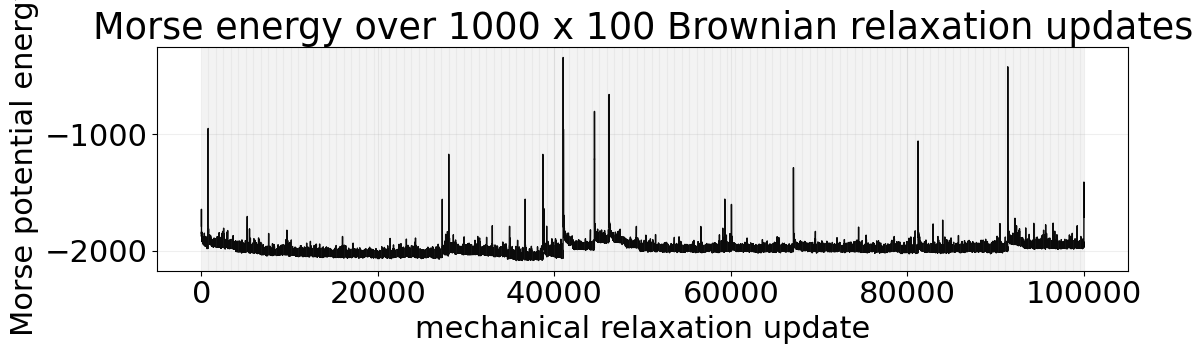

In [45]:
energy = energy_trace["energy"]
outer_energy = energy.reshape(N_STEPS, RELAXATION_STEPS)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(np.arange(energy.shape[0]), energy, color="black", linewidth=1.0)
for boundary in range(RELAXATION_STEPS, energy.shape[0], RELAXATION_STEPS):
    ax.axvline(boundary, color="gray", alpha=0.08, linewidth=0.8)
ax.set_xlabel("mechanical relaxation update")
ax.set_ylabel("Morse potential energy")
ax.set_title(f"Morse energy over {N_STEPS} x {RELAXATION_STEPS} Brownian relaxation updates")
ax.grid(alpha=0.2)
fig.tight_layout()

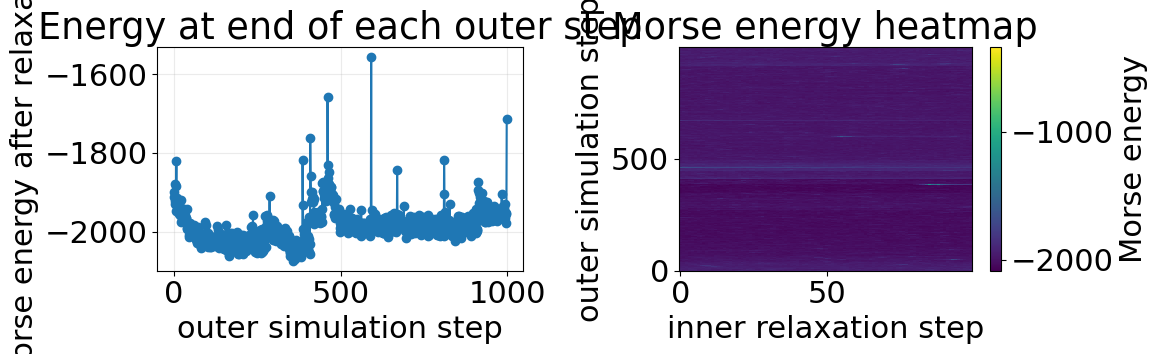

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(N_STEPS), outer_energy[:, -1], marker="o", linewidth=1.5)
axes[0].set_xlabel("outer simulation step")
axes[0].set_ylabel("Morse energy after relaxation")
axes[0].set_title("Energy at end of each outer step")
axes[0].grid(alpha=0.25)

im = axes[1].imshow(
    outer_energy,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
)
axes[1].set_xlabel("inner relaxation step")
axes[1].set_ylabel("outer simulation step")
axes[1].set_title("Morse energy heatmap")
fig.colorbar(im, ax=axes[1], label="Morse energy")

fig.tight_layout()

# Load Pattern Results

In [47]:
def _count_eqx_arrays(path):
    """Count NumPy arrays in an Equinox leaf stream without deserializing a PyTree."""
    count = 0
    with open(path, "rb") as fh:
        while True:
            try:
                onp.load(fh, allow_pickle=False)
                count += 1
            except EOFError:
                break
    return count


def _get_hyper(opt_hyper, lower_name, upper_name=None, default=None):
    if lower_name in opt_hyper:
        return opt_hyper[lower_name]
    if upper_name is not None and upper_name in opt_hyper:
        return opt_hyper[upper_name]
    return default


def pattern_loss_kwargs_from_hyper(opt_hyper):
    defaults = pattern_model.pattern_loss.__kwdefaults__ or {}
    return {
        name: float(_get_hyper(opt_hyper, name, name.upper(), default))
        for name, default in defaults.items()
        if name != "pattern"
    }


def load_run_data_patterns(run_id, root="trained_models_patterns_salt_pepper_sweep/wfrac_0/w12_0/ratio_1-1-4/ncells_60"):
    """Load training log, initial state, and trained model for a pattern run."""
    root = Path(root)
    with open(root / "train-pattern-opt-hyperparams.json", "r") as f:
        opt_hyper = json.load(f)

    run_dir = root / f"train-pattern-{run_id}"
    progress_path = run_dir / "training_progress.json"
    with open(progress_path, "r") as f:
        progress = json.load(f)

    TrainingLog = namedtuple("TrainingLog", ["loss", "val_loss"])
    train_loss = [row["train_loss"] for row in progress]
    val_loss = [row["val_loss"] for row in progress] if progress and progress[0].get("val_loss") is not None else None
    training_log = TrainingLog(train_loss, val_loss)

    n_cells = int(_get_hyper(opt_hyper, "n_cells", "N_CELLS", 60))
    type_ratios = np.asarray(_get_hyper(opt_hyper, "type_ratios", "TYPE_RATIOS", [1.0, 1.0, 1.0]), dtype=float)
    initial_type_fractions = np.asarray(
        opt_hyper.get("initial_type_fractions", type_ratios / type_ratios.sum()),
        dtype=float,
    )

    key = jax.random.PRNGKey(0)
    istate = pattern_model.build_istate(key, n_cells=n_cells, type_ratios=type_ratios)
    model_template = pattern_model.build_model(
        np.array([2.0, 2.0, 2.0, 2.0, 2.0, 2.0]),
        initial_type_fractions=initial_type_fractions,
    )

    with open(run_dir / f"init-pattern-{run_id}.eqx", "rb") as fh:
        initial_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    with open(run_dir / f"trained-pattern-{run_id}.eqx", "rb") as fh:
        trained_model = eqx.tree_deserialise_leaves(fh, like=model_template)

    print(f"Loaded {len(train_loss)} logged epochs from {progress_path}")
    print(f"Initial ratios: {type_ratios.tolist()}; initial fractions: {initial_type_fractions.tolist()}")
    return opt_hyper, training_log, istate, initial_model, trained_model

# Single Run

In [48]:
RUN_ID = 0

In [49]:
opt_hyper, training_log, istate, initial_model, trained_model = load_run_data_patterns(
    RUN_ID
)

Loaded 201 logged epochs from trained_models_patterns_salt_pepper_sweep/wfrac_0/w12_0/ratio_1-1-4/ncells_60/train-pattern-0/training_progress.json
Initial ratios: [1.0, 1.0, 4.0]; initial fractions: [0.16666666666666666, 0.16666666666666666, 0.6666666666666666]


## Loss Curves


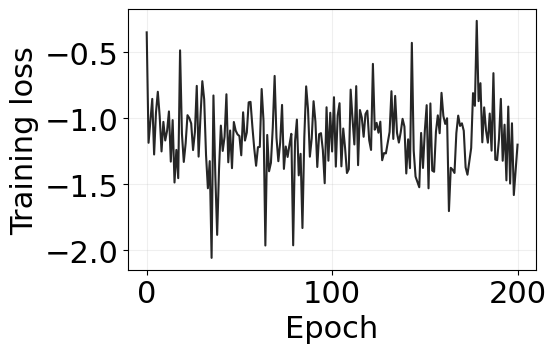

In [50]:
epochs = np.arange(len(training_log.loss))

if training_log.val_loss is None:
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    ax.plot(epochs, training_log.loss, color="black", alpha=0.85)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Training loss")
    ax.grid(alpha=0.2)
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(epochs, training_log.loss, color="black", alpha=0.85)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Training loss")
    ax[0].grid(alpha=0.2)

    ax[1].plot(epochs, training_log.val_loss, color="maroon", alpha=0.85)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Validation loss")
    ax[1].grid(alpha=0.2)

fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(f"figures/loss_curves_{EXPERIMENT}-{RUN_ID}.svg", dpi=300)

## Forward Comparison


In [51]:
def _simulate_final_state(model, istate, key, n_sim_steps):
    result = jxm.simulate(model, istate, key, n_sim_steps)
    return result[0] if isinstance(result, tuple) else result


TRAINED_OUTDIR = NOTEBOOK_DIR / "trained_pattern_forward_outputs"
TRAINED_OUTDIR.mkdir(exist_ok=True)

PATTERN = _get_hyper(opt_hyper, "pattern", "PATTERN", "salt-pepper-shell")
N_SIM_STEPS = int(_get_hyper(opt_hyper, "n_steps", "N_STEPS", 50))
loss_kwargs = pattern_loss_kwargs_from_hyper(opt_hyper)

initial_j = pattern_model.visible_j_from_raw_j(initial_model.raw_j)
trained_j = pattern_model.visible_j_from_raw_j(trained_model.raw_j)
initial_frac = pattern_model.visible_fractions_from_raw_fractions(initial_model.raw_fractions)
trained_frac = pattern_model.visible_fractions_from_raw_fractions(trained_model.raw_fractions)

key = jax.random.PRNGKey(random.randint(0, 10000))
key, initial_type_key, trained_type_key, initial_sim_key, trained_sim_key = jax.random.split(key, 5)
istate_initial_model, _ = pattern_model.sample_initial_celltypes(initial_model, istate, initial_type_key)
istate_trained_model, _ = pattern_model.sample_initial_celltypes(trained_model, istate, trained_type_key)

fstate_initial_model = _simulate_final_state(initial_model, istate_initial_model, initial_sim_key, N_SIM_STEPS)
fstate_trained_model = _simulate_final_state(trained_model, istate_trained_model, trained_sim_key, N_SIM_STEPS)

base_state_loss = float(pattern_model.pattern_loss(istate, pattern=PATTERN, **loss_kwargs))
initial_model_loss = float(pattern_model.pattern_loss(fstate_initial_model, pattern=PATTERN, **loss_kwargs))
trained_model_loss = float(pattern_model.pattern_loss(fstate_trained_model, pattern=PATTERN, **loss_kwargs))

print("loss kwargs from training hyperparameters:", loss_kwargs)
print("initial J:", onp.asarray(initial_j).tolist())
print("trained J:", onp.asarray(trained_j).tolist())
print("initial fractions:", onp.asarray(initial_frac).tolist())
print("trained fractions:", onp.asarray(trained_frac).tolist())
print(f"base initial state loss: {base_state_loss:.4f}")
print(f"final state with initial J/fractions loss: {initial_model_loss:.4f}")
print(f"final state with trained J/fractions loss: {trained_model_loss:.4f}")


loss kwargs from training hyperparameters: {'shell_distance_weight': 1.0, 'w12': 0.0, 'w33': 1.0, 'w_media1': 10.0, 'w_media2': 10.0, 'w_media3': 10.0}
initial J: [3.594482469691293, 0.875252667312505, 2.246631612783293, 1.8769080092083754, 2.870541479403501, 0.9465900825385005]
trained J: [3.748183166201523, 0.8278511281417884, 1.1892766941441102, 3.0547715957729613, 1.1385107355095658, 1.0353760778698002]
initial fractions: [0.16666666666666666, 0.16666666666666666, 0.6666666666666666]
trained fractions: [0.035061988649329245, 0.01792868887017185, 0.947009322480499]
base initial state loss: 0.1606
final state with initial J/fractions loss: -0.6880
final state with trained J/fractions loss: -1.3673


## Trained Loss Contribution Diagnostics


In [52]:
target_fractions = onp.asarray(opt_hyper.get("initial_type_fractions", opt_hyper.get("type_ratios", [1.0, 1.0, 1.0])), dtype=float)
target_fractions = target_fractions / target_fractions.sum()
w_frac = float(_get_hyper(opt_hyper, "w_frac", "W_FRAC", 0.0))

base_loss_breakdown = print_loss_contribution_summary(
    "base initial state loss breakdown",
    istate,
    pattern=PATTERN,
    model=trained_model,
    target_fractions=target_fractions,
    w_frac=w_frac,
    **loss_kwargs,
)
initial_j_loss_breakdown = print_loss_contribution_summary(
    "final state with initial J/fractions loss breakdown",
    fstate_initial_model,
    pattern=PATTERN,
    model=initial_model,
    target_fractions=target_fractions,
    w_frac=w_frac,
    **loss_kwargs,
)
trained_loss_breakdown = print_loss_contribution_summary(
    "final state with trained J/fractions loss breakdown",
    fstate_trained_model,
    pattern=PATTERN,
    model=trained_model,
    target_fractions=target_fractions,
    w_frac=w_frac,
    **loss_kwargs,
)

base initial state loss breakdown
weighted terms:
{
  "shell_distance": -1.4208798662070519,
  "media_1_penalty": 1.37117769423993,
  "media_2_penalty": 1.4241300011896543,
  "media_3_reward": -1.3346317873127511,
  "contact_33_penalty": 0.12083237651660325,
  "contact_12_reward": -0.0
}
weighted_total: 0.160628
pattern_loss: 0.160628
final state with initial J/fractions loss breakdown
weighted terms:
{
  "shell_distance": -1.4990659083313296,
  "media_1_penalty": 0.9766983166307479,
  "media_2_penalty": 1.2151242867006127,
  "media_3_reward": -1.4851395455743386,
  "contact_33_penalty": 0.10440302568963135,
  "contact_12_reward": -0.0
}
weighted_total: -0.687980
pattern_loss: -0.687980
final state with trained J/fractions loss breakdown
weighted terms:
{
  "shell_distance": -1.626105185003508,
  "media_1_penalty": 1.1495785290929952,
  "media_2_penalty": 1.1082913843195588,
  "media_3_reward": -2.07258462227708,
  "contact_33_penalty": 0.07353124877874283,
  "contact_12_reward": -0.0


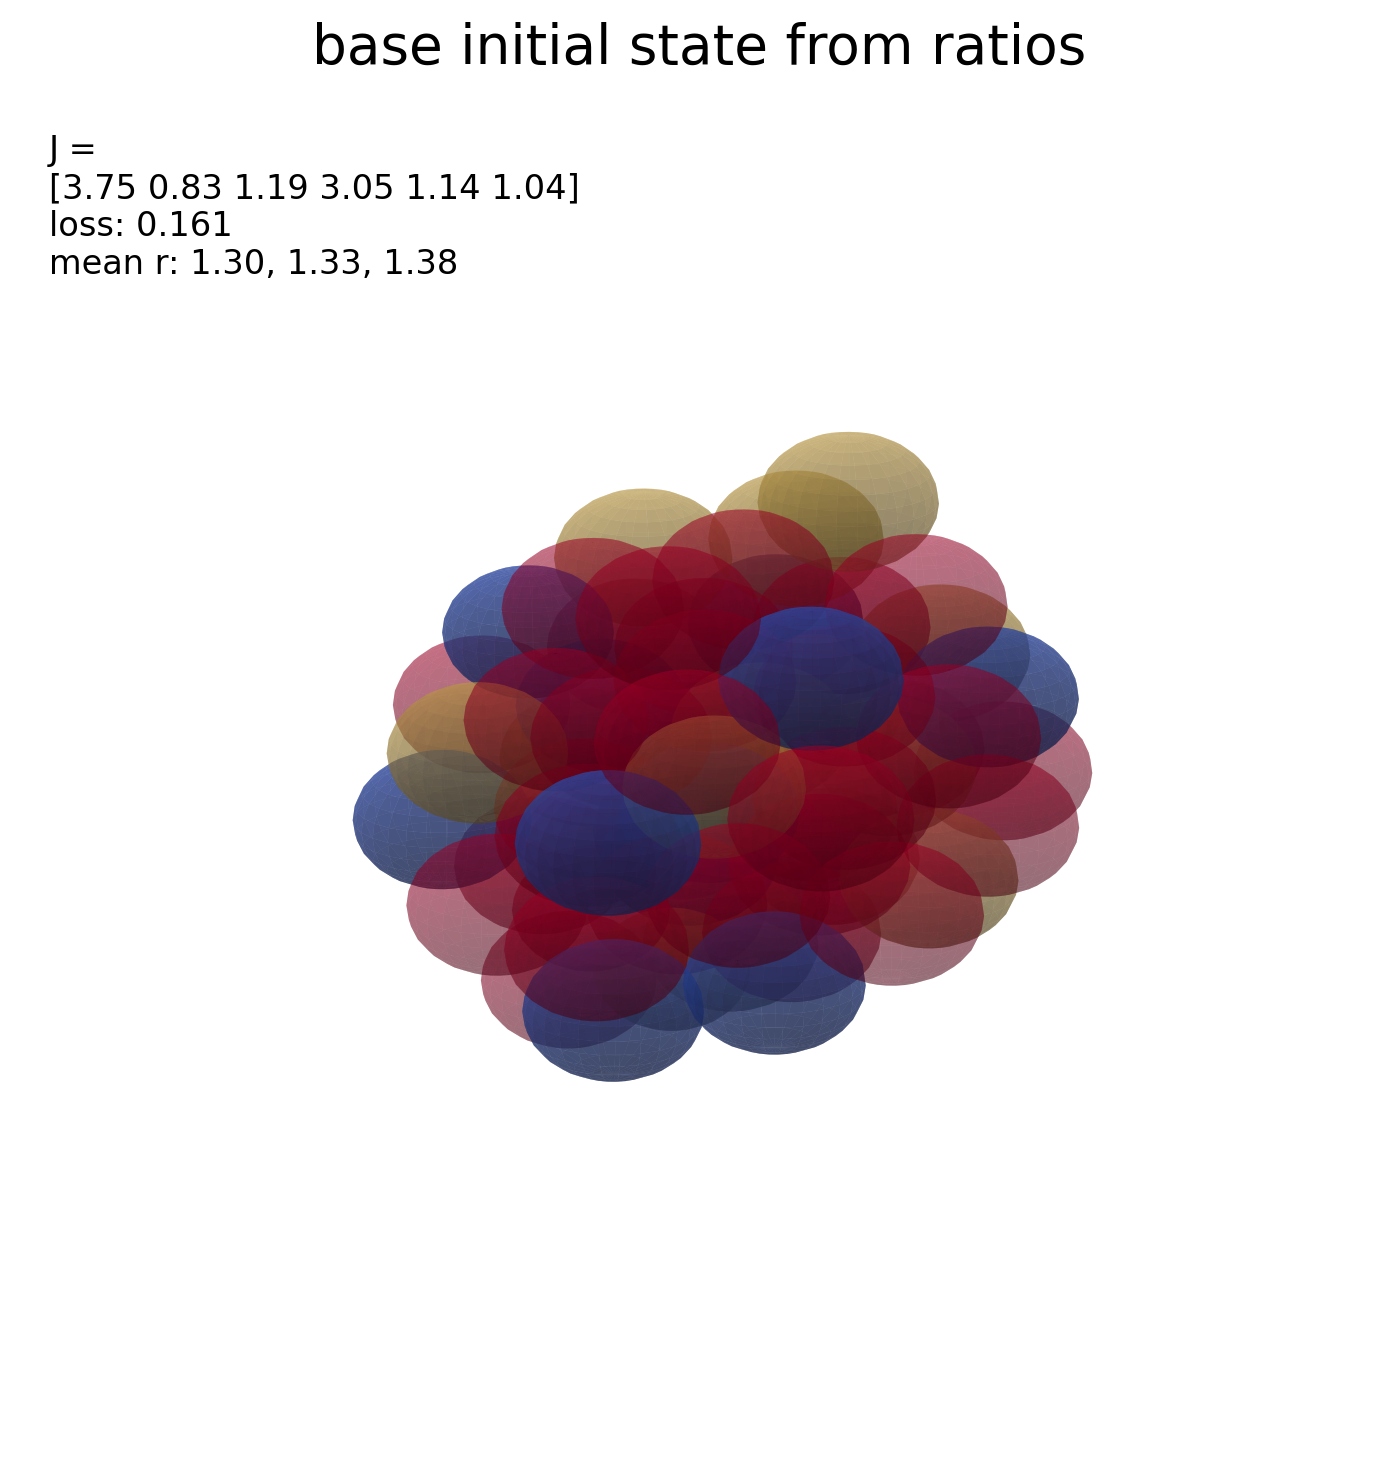

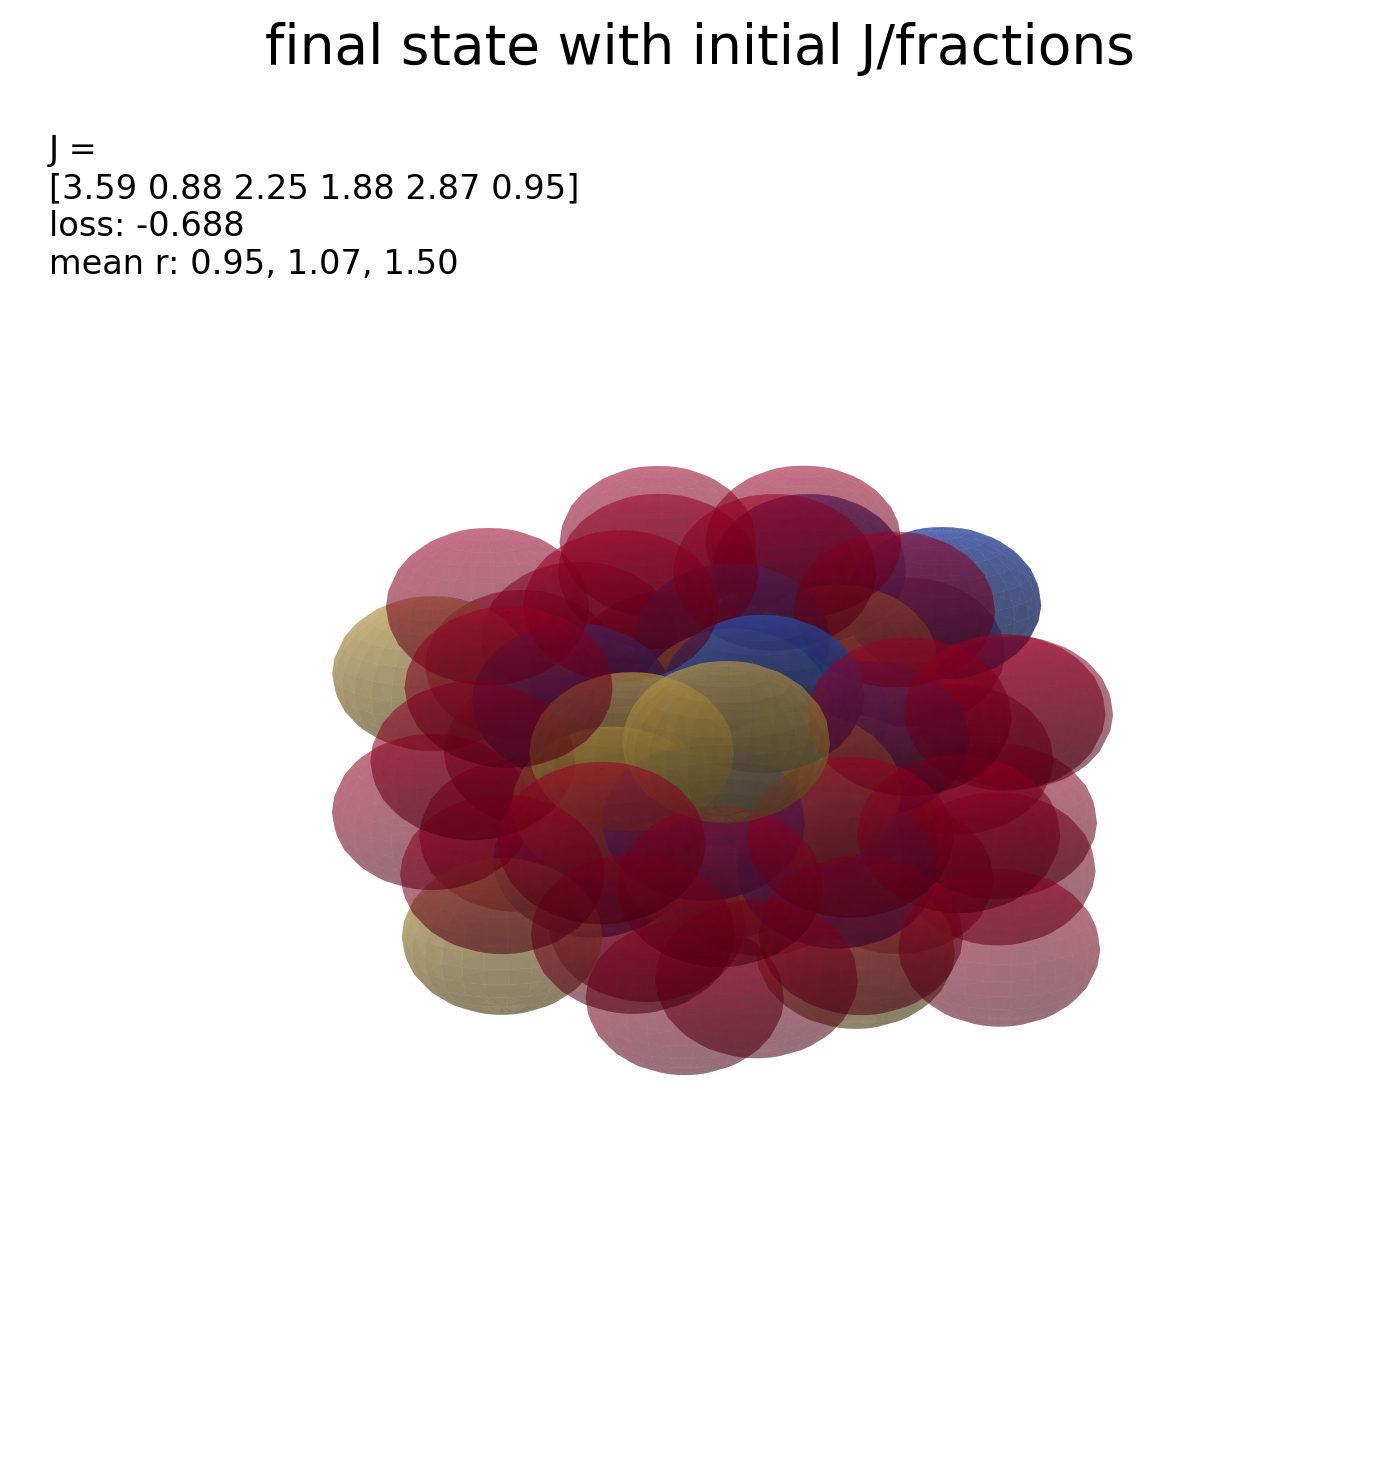

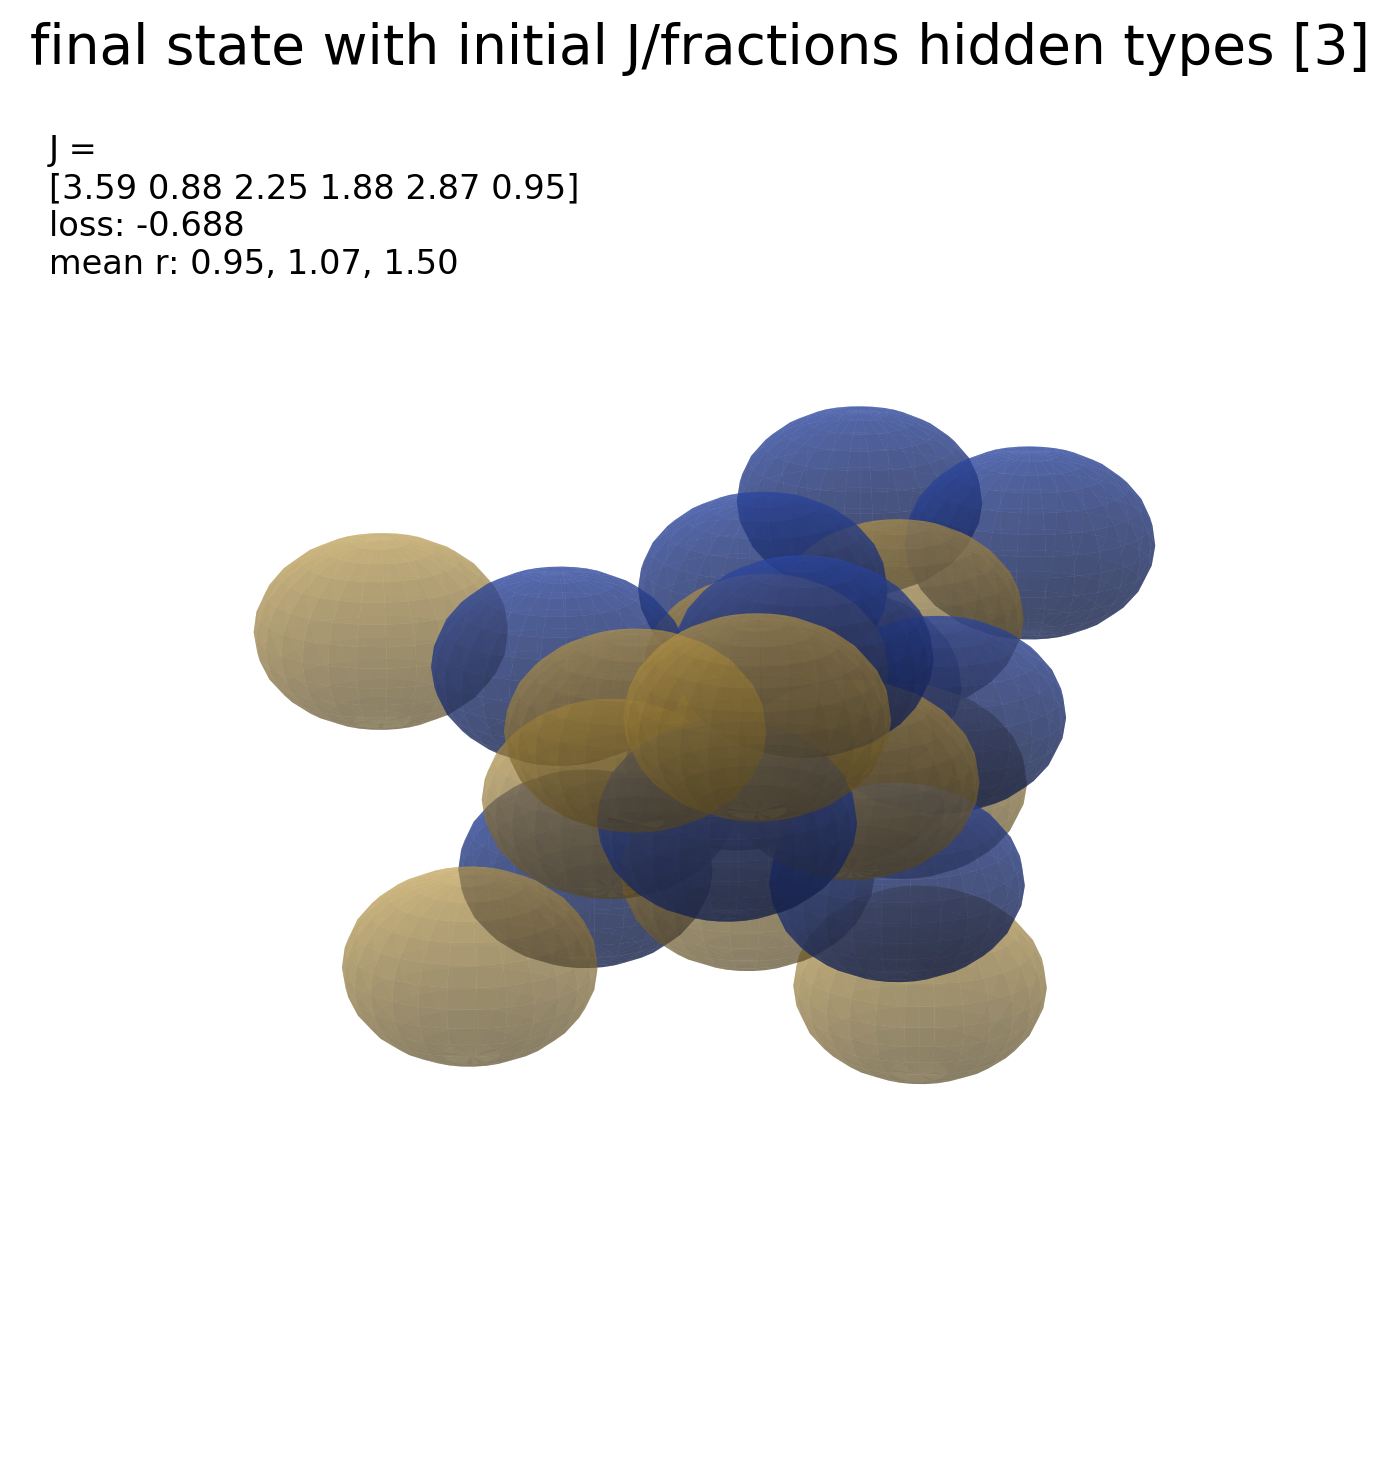

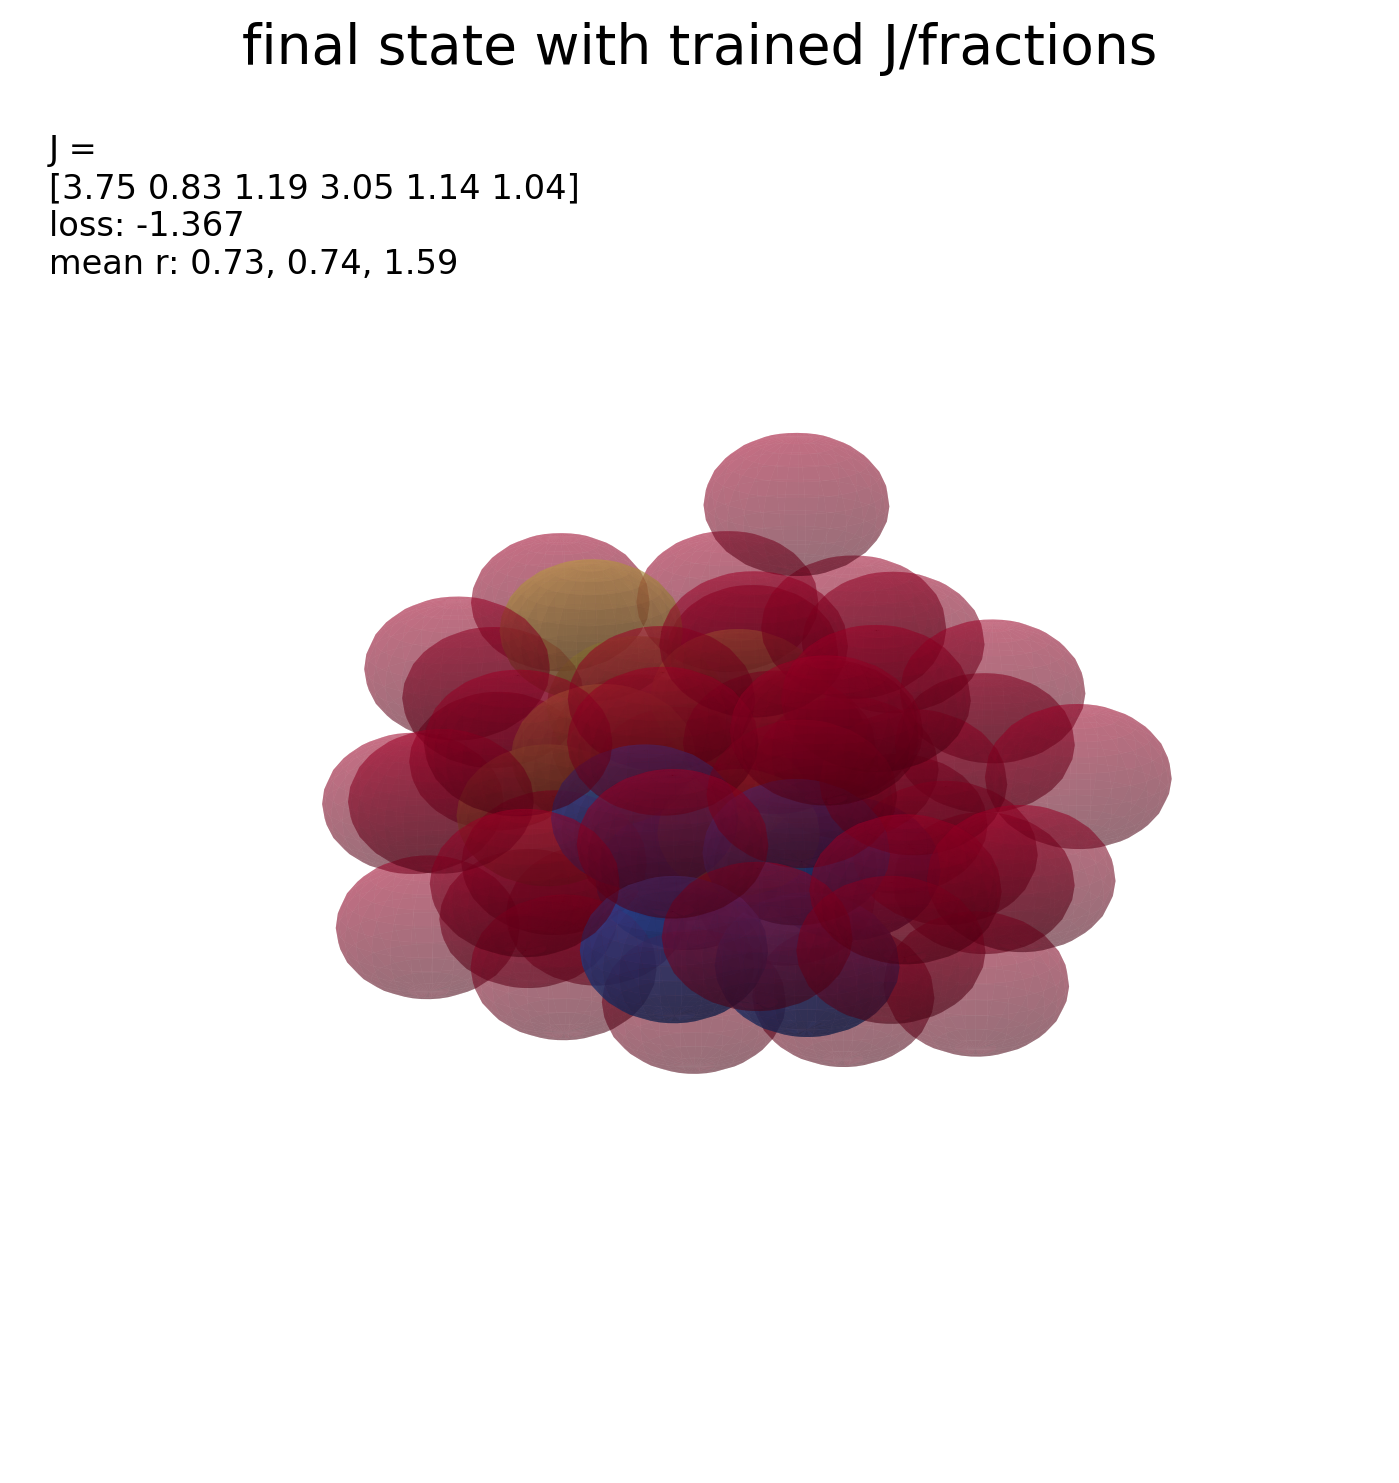

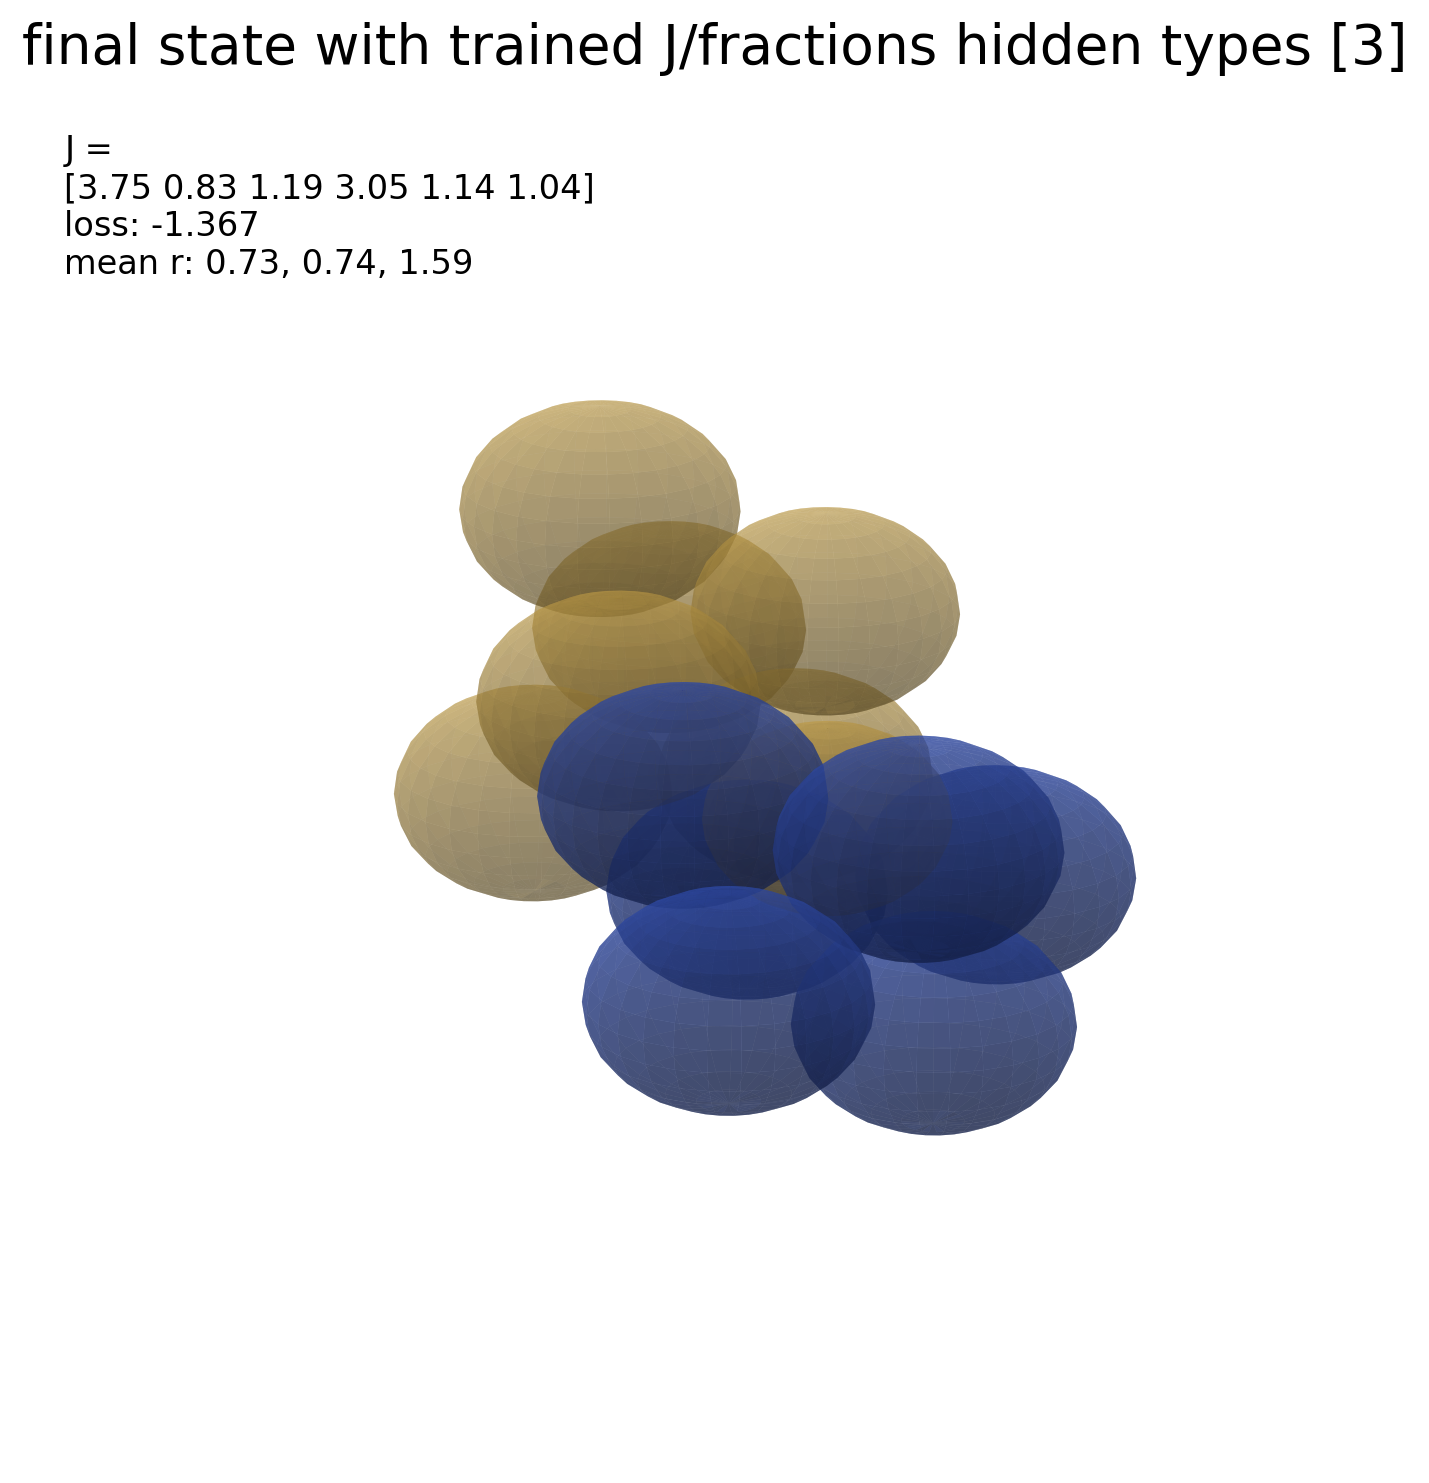

In [53]:
base_preview = save_pattern_state_visualization(
    outdir=TRAINED_OUTDIR,
    state=istate,
    title="base initial state from ratios",
    filename=f"{EXPERIMENT}-{RUN_ID}-base-initial-state.png",
    target_j=trained_j,
    pattern=PATTERN,
    **loss_kwargs,
)

untrained_preview = save_pattern_state_visualization(
    outdir=TRAINED_OUTDIR,
    state=fstate_initial_model,
    title="final state with initial J/fractions",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-initial-j.png",
    target_j=initial_j,
    pattern=PATTERN,
    hidden_types=HIDE_TYPES,
    **loss_kwargs,
)

trained_preview = save_pattern_state_visualization(
    outdir=TRAINED_OUTDIR,
    state=fstate_trained_model,
    title="final state with trained J/fractions",
    filename=f"{EXPERIMENT}-{RUN_ID}-final-trained-j.png",
    target_j=trained_j,
    pattern=PATTERN,
    hidden_types=HIDE_TYPES,
    **loss_kwargs,
)

display_preview(base_preview, width=360)
display_preview(untrained_preview, width=360)
display_preview(trained_preview, width=360)

## Trained Contact And Pair-Distance Diagnostics


trained model final pair distances
{
  "11": 0.4179345306217869,
  "12": 0.18942068041743698,
  "13": 0.09865863504444075,
  "22": 0.41211620212280875,
  "23": 0.10254243533717192,
  "33": 0.07353124877874283
}


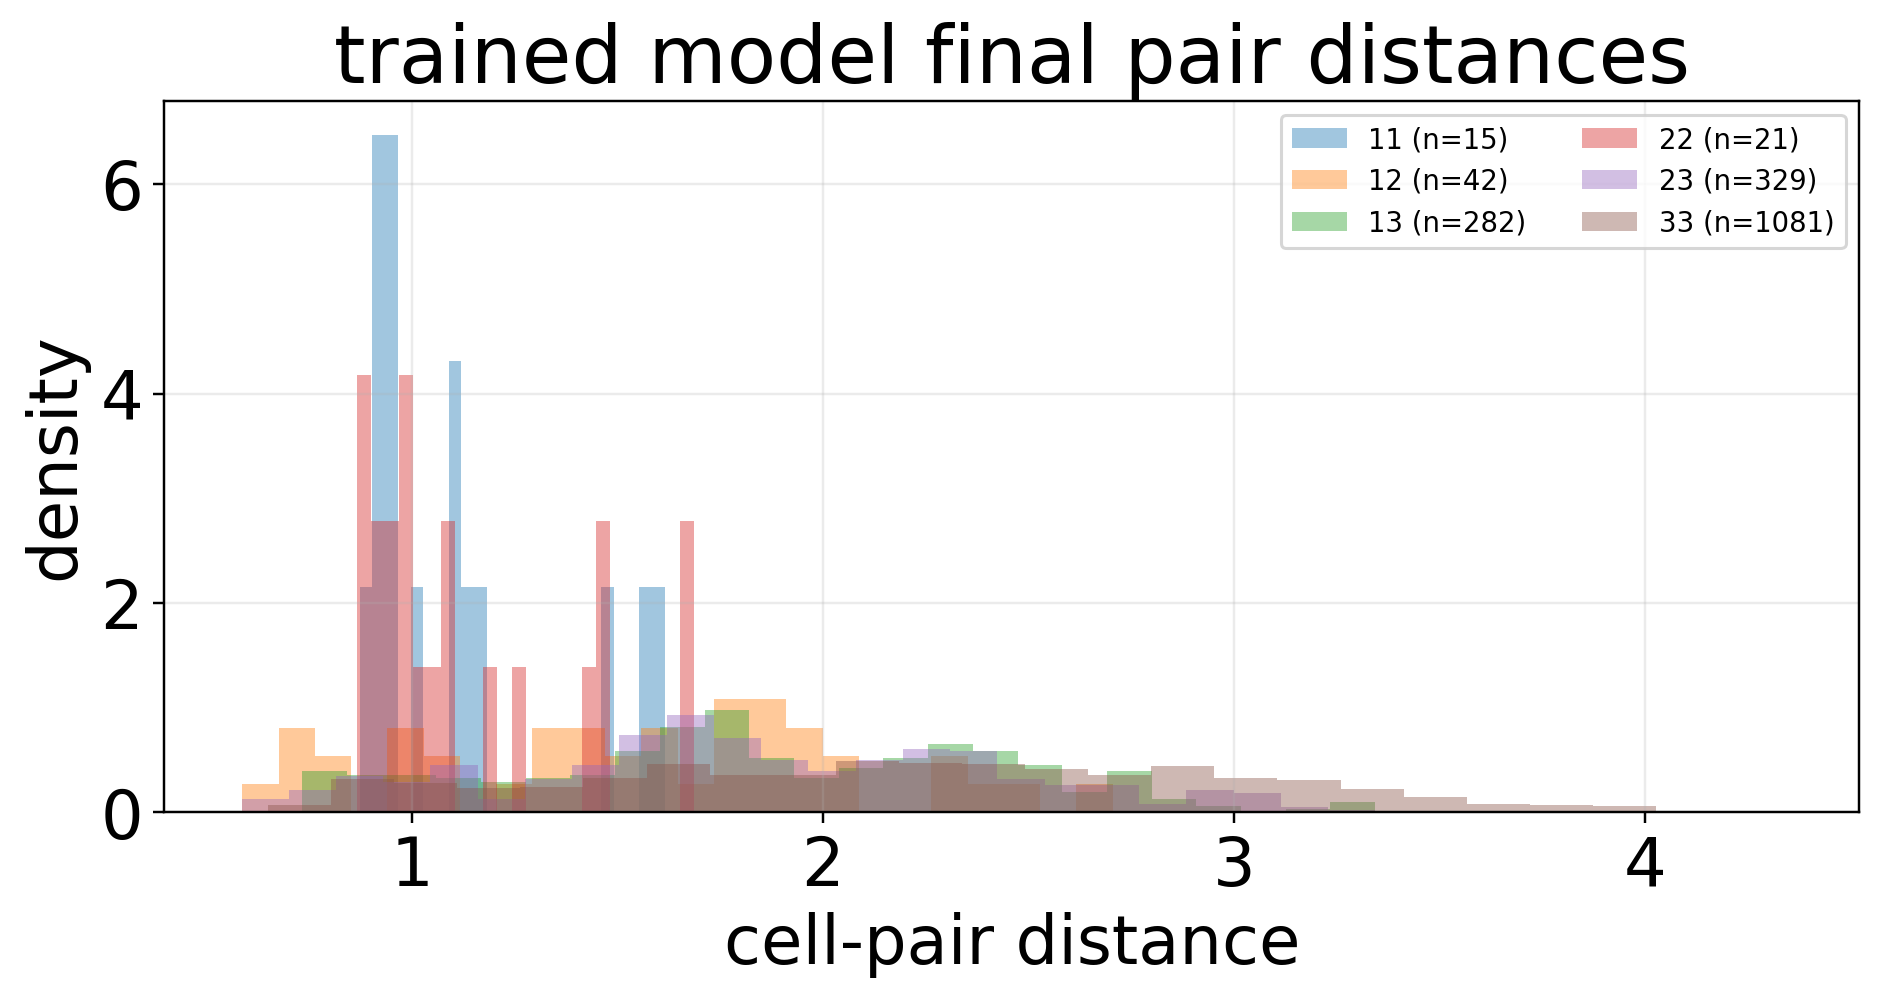

initial J final pair distances
{
  "11": 0.24960232621959527,
  "12": 0.2743642042429092,
  "13": 0.11674565171726078,
  "22": 0.19308691068395933,
  "23": 0.09167554544145602,
  "33": 0.10440302568963135
}


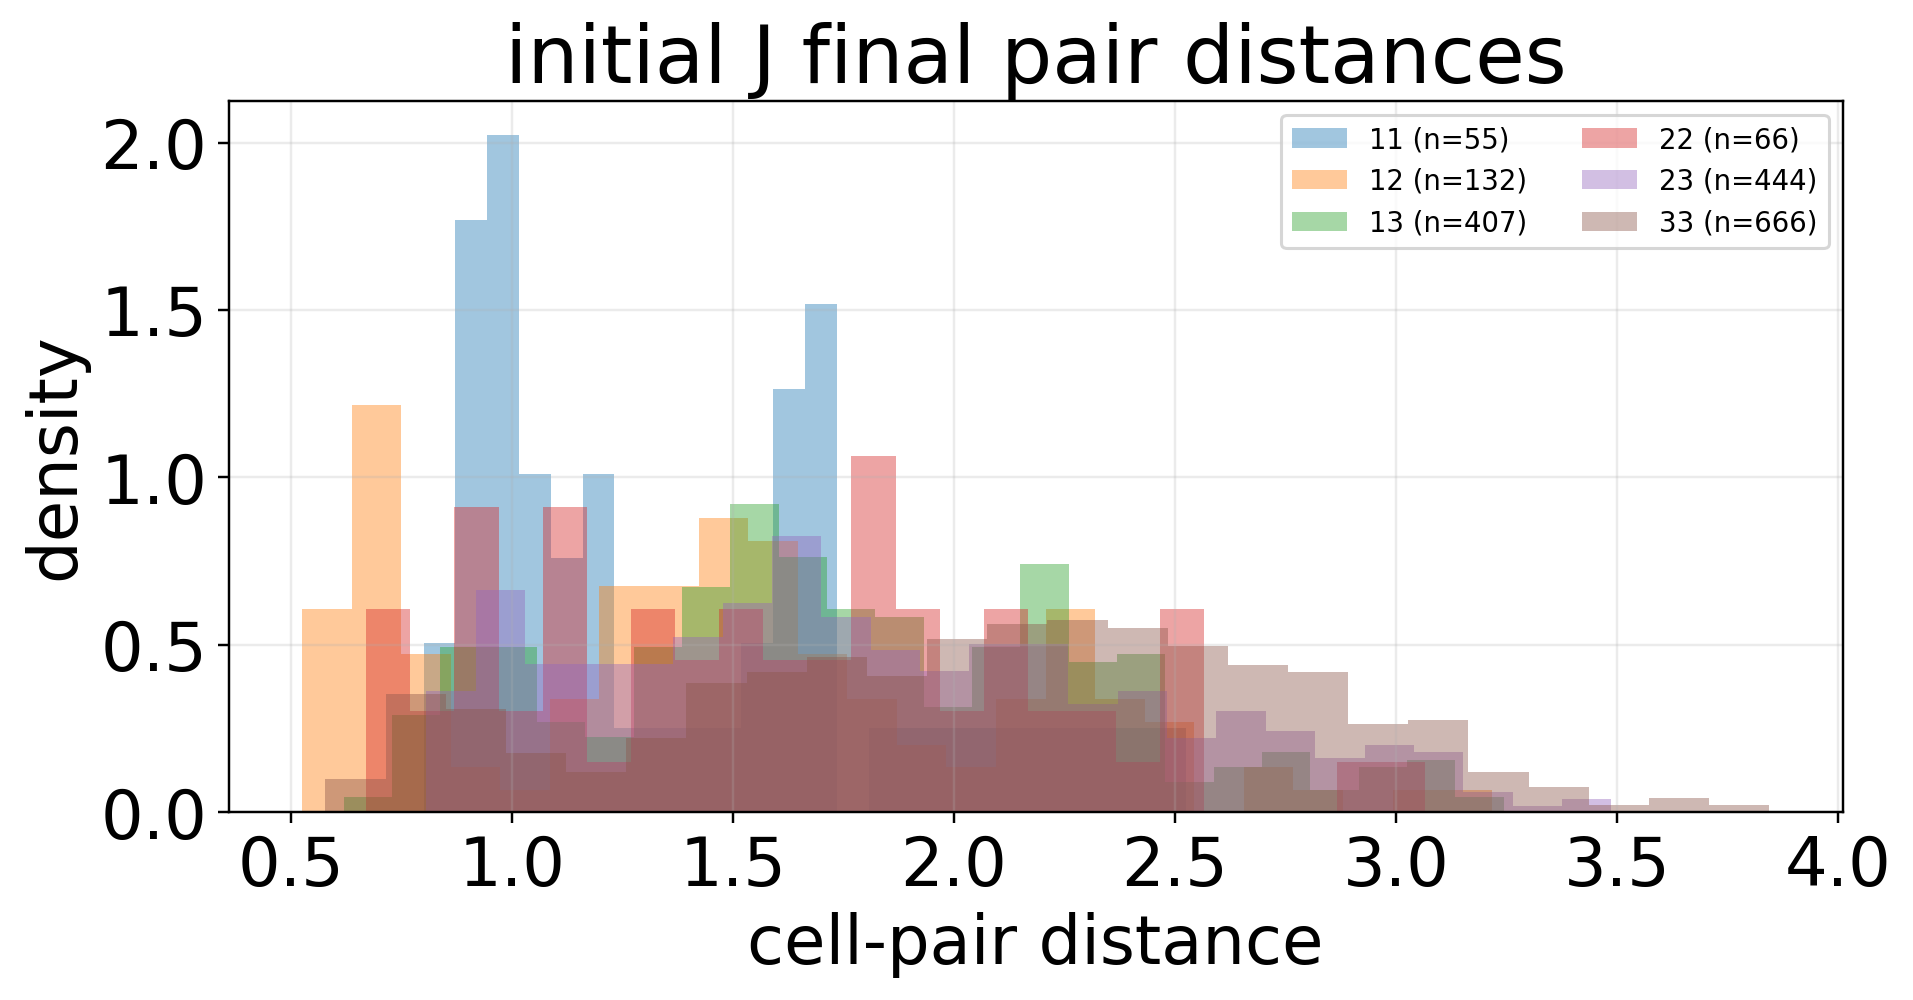

In [54]:
trained_distance_diagnostics = show_contact_and_distance_diagnostics(
    state=fstate_trained_model,
    outdir=TRAINED_OUTDIR,
    filename=f"{EXPERIMENT}-{RUN_ID}-final-trained-pair-distance-distribution.png",
    title="trained model final pair distances",
)

initial_j_distance_diagnostics = show_contact_and_distance_diagnostics(
    state=fstate_initial_model,
    outdir=TRAINED_OUTDIR,
    filename=f"{EXPERIMENT}-{RUN_ID}-final-initial-j-pair-distance-distribution.png",
    title="initial J final pair distances",
)